In [1]:
# ==============================
# Gradient Boosting -Comparision Model
# ==============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [13]:
# ==============================
# Load Dataset
# ==============================

data = pd.read_csv("../data/processed/patient_state_clean.csv")

print("Dataset Shape:", data.shape)
data.head()


Dataset Shape: (2899, 12)


,SEQN,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Glucose,HbA1c,Insulin,Total_Cholesterol,HDL_Cholesterol,Metabolic_Risk
0,93708.0,66.0,1.0,23.7,141.000000,77.000000,122.0,6.2,9.72,209.0,88.0,1
1,93711.0,56.0,0.0,21.3,101.333333,66.666667,107.0,5.7,5.28,238.0,72.0,1
2,93717.0,22.0,0.0,24.5,118.666667,65.333333,91.0,5.1,3.94,213.0,53.0,0
3,93718.0,45.0,0.0,22.0,131.333333,90.000000,89.0,5.7,4.89,152.0,63.0,1
4,93719.0,13.0,1.0,26.0,101.333333,64.000000,86.0,5.0,10.94,97.0,46.0,0


In [14]:
# ==============================
# Define Features and Target
# ==============================

FEATURES = [
    "Age", "Gender", "BMI",
    "Systolic_BP", "Diastolic_BP",
    "Glucose", "Insulin",
    "Total_Cholesterol", "HDL_Cholesterol"
]

X = data[FEATURES]
y = data["Metabolic_Risk"]


In [15]:
# ==============================
# Train-Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [16]:
# ==============================
# 5-Fold Cross Validation
# ==============================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gb_model = GradientBoostingClassifier(random_state=42)

cv_scores = cross_val_score(
    gb_model,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("Cross-Validation F1 Scores:", cv_scores)
print("Mean CV F1:", round(np.mean(cv_scores), 3))
print("Std CV F1:", round(np.std(cv_scores), 3))


Cross-Validation F1 Scores: [0.66666667 0.74770642 0.71840355 0.72566372 0.70246085]
Mean CV F1: 0.712
Std CV F1: 0.027


In [17]:
# ==============================
# Train Final Model
# ==============================

gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)


In [18]:
# ==============================
# Model Evaluation
# ==============================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Gradient Boosting - Final Test Results")
print("Accuracy:", round(accuracy,3))
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1 Score:", round(f1,3))


Gradient Boosting - Final Test Results
Accuracy: 0.752
Precision: 0.716
Recall: 0.637
F1 Score: 0.674


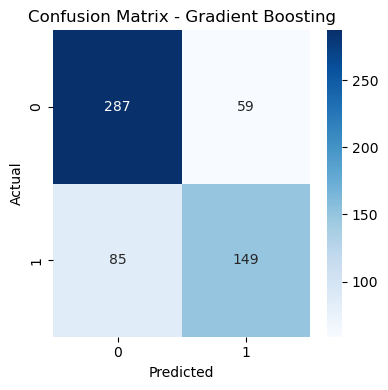

In [19]:
# ==============================
# Confusion Matrix
# ==============================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gradient Boosting")
plt.tight_layout()
plt.show()


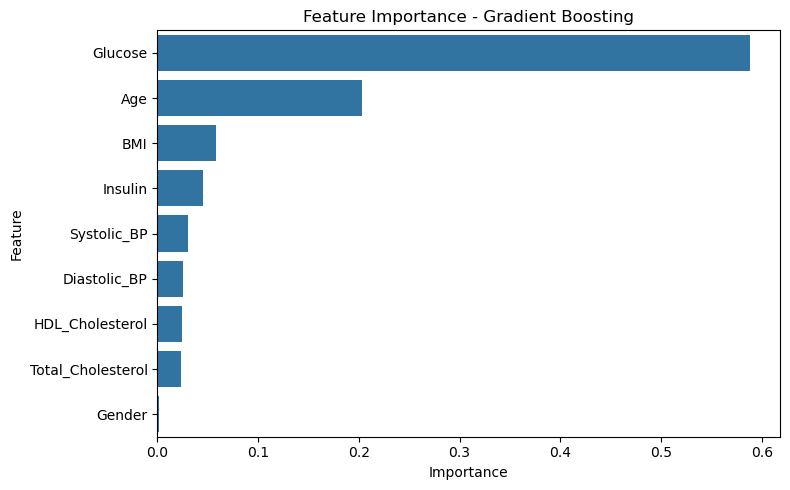

,Feature,Importance
5,Glucose,0.588611
0,Age,0.203064
2,BMI,0.058077
6,Insulin,0.045143
3,Systolic_BP,0.030327
4,Diastolic_BP,0.025860
8,HDL_Cholesterol,0.024763
7,Total_Cholesterol,0.022995
1,Gender,0.001162


In [20]:
# ==============================
# Feature Importance
# ==============================

feature_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": gb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Gradient Boosting")
plt.tight_layout()
plt.show()

feature_importance


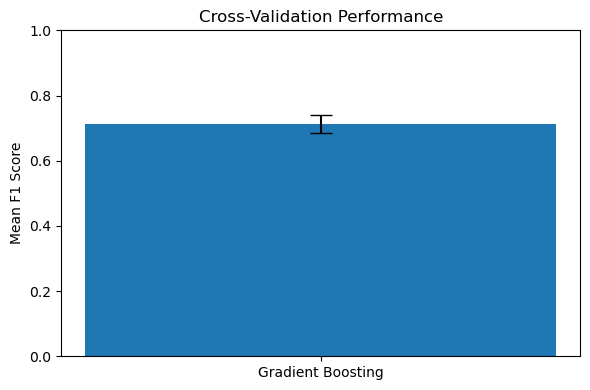

In [21]:
# ==============================
# CV Stability Visualization
# ==============================

plt.figure(figsize=(6,4))
plt.bar(["Gradient Boosting"], [np.mean(cv_scores)],
        yerr=[np.std(cv_scores)], capsize=8)

plt.ylabel("Mean F1 Score")
plt.title("Cross-Validation Performance")
plt.ylim(0,1)
plt.tight_layout()
plt.show()
